# Analisis de conjunto de datos de viajes

Análisis de conjunto de datos con puntos con las ubicaciones de paradas y de puntos de control de horario de los recorridos de los ómnibus [https://catalogodatos.gub.uy/dataset/transporte-colectivo-paradas-puntos-de-control-y-recorridos-de-omnibus]

La información del transporte se dispone en 2 archivos:

- Paradas (v_uptu_paradas): ubicación de paradas de ómnibus
- Controles (v_uptu_controles): ubicación de puntos de control de horario Paradas y Controles tienen en común con las Líneas de ómnibus, origen y destino el campo identificador de la variante de recorrido de la línea. 

En particular, utilizaremos únicamente el de paradas para poder cruzarlo con el dataset de viajes.


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from unidecode import unidecode
import dbf
import os

import warnings
warnings.filterwarnings("ignore")

import sys
sys.path.append(os.path.abspath(".."))
from utils import descargar_datasets, corregir_tildes, graficar_sobre_mapa

## Descarga y carga de los datos

In [3]:
descargar_datasets(datasets="paradas", carpeta="../datasets")

Descargando: v_uptu_paradas.zip...
✅ v_uptu_paradas.zip guardado.


Los datasets se encuentran disponibles en la ruta:  /home/bruno/Escritorio/REPO PROYECTO GRAFOS/REVISANDO/analisis_datasets/../datasets


In [4]:
path_paradas = "../datasets/paradas/v_uptu_paradas.shp"
gdf = gpd.read_file(path_paradas, encoding='utf-8')

display(gdf.head())

,COD_UBIC_P,DESC_LINEA,COD_VARIAN,ORDINAL,CALLE,ESQUINA,COD_CALLE1,COD_CALLE2,X,Y,geometry
0,546.0,144,883,44,CORUÑA,GRAL JULIO AMADEO ROLETTI,2187.0,6120.0,577981.398033,6.140775e+06,POINT (577981.398 6140774.574)
1,546.0,144,3225,46,CORUÑA,GRAL JULIO AMADEO ROLETTI,2187.0,6120.0,577981.398033,6.140775e+06,POINT (577981.398 6140774.574)
2,547.0,144,883,45,CORUÑA,JUAN FRANCISCO MARTINEZ,2187.0,4257.0,577902.796993,6.140892e+06,POINT (577902.797 6140892.492)
3,547.0,144,3225,47,CORUÑA,JUAN FRANCISCO MARTINEZ,2187.0,4257.0,577902.796993,6.140892e+06,POINT (577902.797 6140892.492)
4,548.0,144,888,20,CORUÑA,SAN ANTONIO,2187.0,6279.0,577926.505890,6.140845e+06,POINT (577926.506 6140844.778)


De este dataset, nos interesan principalmente el codigo de parada (COD_UBIC_P) y las coordenadas de dicha parada.

In [5]:
columnas_que_sirven = ['COD_UBIC_P', 'CALLE', 'ESQUINA', 'COD_CALLE1', 'COD_CALLE2', 'X', 'Y', 'geometry']
gdfdrop = gdf[columnas_que_sirven].drop_duplicates(subset=['COD_UBIC_P'])

gdfdrop.head()

,COD_UBIC_P,CALLE,ESQUINA,COD_CALLE1,COD_CALLE2,X,Y,geometry
0,546.0,CORUÑA,GRAL JULIO AMADEO ROLETTI,2187.0,6120.0,577981.398033,6.140775e+06,POINT (577981.398 6140774.574)
2,547.0,CORUÑA,JUAN FRANCISCO MARTINEZ,2187.0,4257.0,577902.796993,6.140892e+06,POINT (577902.797 6140892.492)
4,548.0,CORUÑA,SAN ANTONIO,2187.0,6279.0,577926.505890,6.140845e+06,POINT (577926.506 6140844.778)
6,549.0,CORUÑA,AGACES,2187.0,120.0,577776.314160,6.141078e+06,POINT (577776.314 6141077.736)
8,550.0,CORUÑA,AGACES,2187.0,120.0,577751.540270,6.141104e+06,POINT (577751.54 6141103.685)


In [6]:
print("Existen", gdfdrop['COD_UBIC_P'].nunique(), "paradas en el dataset.")

Existen 4933 paradas en el dataset.


## Exploración y transformación de los datos

Segun la documentación, este dataset contiene:

* cod_ubic_parada: Código de parada
* cod_variante: Código de variante
* ordinal: Ordinal
* calle: Calle ubicación de parada
* esquina: Esquina ubicación de parada
* cod_calle1: Código calle ubicación de parada
* cod_calle2: Código calle esquina de parada
* x: Coordenada X
* y: Coordenada Y

Lo primero que notamos es que el sistema de coordenadas no es el usual, por lo que precisamos averiguar cual usa este dataset:

In [7]:
gdfdrop.crs

<Projected CRS: EPSG:32721>
Name: WGS 84 / UTM zone 21S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 60°W and 54°W, southern hemisphere between 80°S and equator, onshore and offshore. Argentina. Bolivia. Brazil. Falkland Islands (Malvinas). Paraguay. Uruguay.
- bounds: (-60.0, -80.0, -54.0, 0.0)
Coordinate Operation:
- name: UTM zone 21S
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

Con esto sabemos que las coordenadas estan en el sistema EPSG:32721.

El sistema al que estamos acostumbrados, el mismo que usa Google Maps, por ejemplo, es el EPSG:4326. El resto de datasets con los que trabajaremos se encuentran en este último, por lo que tendremos que realizarle una transformación a este nuevo dataset para que sean compatibles. 

In [8]:
# Pasamos al sistema de coordenadas que estamos acostumbrados:
# (Esto solo afecta a la columna geometry, que es la que guarda datos espaciales)
gdf_paradas = gdfdrop.to_crs("EPSG:4326")

# Aplico el cambio tambien a las columnas X e Y:
gdf_paradas["X"] = gdf_paradas.geometry.x
gdf_paradas["Y"] = gdf_paradas.geometry.y


# Aprovecho para convertir a int las columnas de codigos
gdf_paradas[["COD_UBIC_P", "COD_CALLE1", "COD_CALLE2"]] = gdf_paradas[["COD_UBIC_P", "COD_CALLE1", "COD_CALLE2"]].astype('Int64')

gdf_paradas.head()

,COD_UBIC_P,CALLE,ESQUINA,COD_CALLE1,COD_CALLE2,X,Y,geometry
0,546,CORUÑA,GRAL JULIO AMADEO ROLETTI,2187,6120,-56.146758,-34.872405,POINT (-56.14676 -34.87241)
2,547,CORUÑA,JUAN FRANCISCO MARTINEZ,2187,4257,-56.147629,-34.871348,POINT (-56.14763 -34.87135)
4,548,CORUÑA,SAN ANTONIO,2187,6279,-56.147365,-34.871776,POINT (-56.14737 -34.87178)
6,549,CORUÑA,AGACES,2187,120,-56.149030,-34.869687,POINT (-56.14903 -34.86969)
8,550,CORUÑA,AGACES,2187,120,-56.149304,-34.869455,POINT (-56.1493 -34.86946)


Con este cambio, ya tenemos el dataset listo para analizar y cruzar con el resto de dataset más adelante.

Se incluye en Utils una función de preprocesamiento que realiza este proceso.

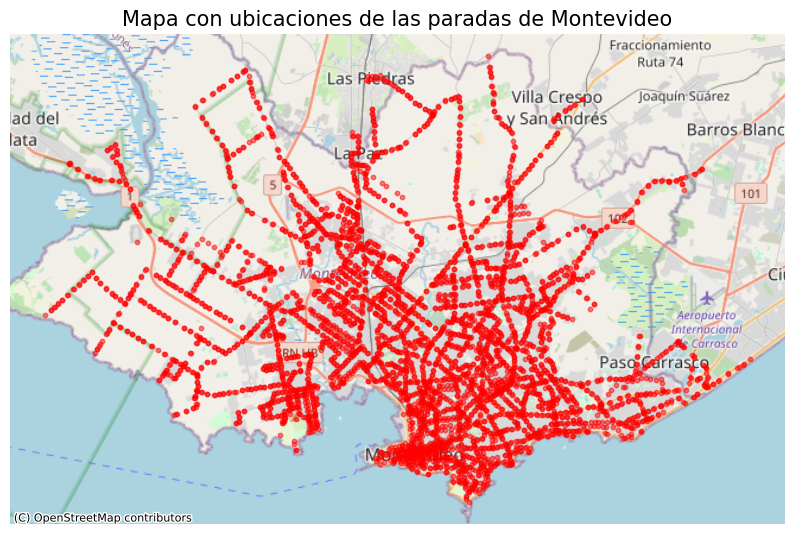

(<Figure size 1000x1000 with 1 Axes>,
 <Axes: title={'center': 'Mapa con ubicaciones de las paradas de Montevideo'}>)

In [9]:
graficar_sobre_mapa(gdf_paradas, titulo="Mapa con ubicaciones de las paradas de Montevideo", color="red", save=True)

In [10]:
gdf_paradas.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 4933 entries, 0 to 42731
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   COD_UBIC_P  4933 non-null   Int64   
 1   CALLE       4925 non-null   object  
 2   ESQUINA     4929 non-null   object  
 3   COD_CALLE1  4931 non-null   Int64   
 4   COD_CALLE2  4931 non-null   Int64   
 5   X           4933 non-null   float64 
 6   Y           4933 non-null   float64 
 7   geometry    4933 non-null   geometry
dtypes: Int64(3), float64(2), geometry(1), object(2)
memory usage: 361.3+ KB


## Cruce con el dataset de viajes

Podemos vincular la ubicación de las paradas con los viajes realizados, podemos ver por hora o por dia que paradas fueron usadas.

In [11]:
descargar_datasets(datasets="viajes", carpeta="../datasets")

Descargando: viajes_stm_092022.zip...
✅ viajes_stm_092022.zip guardado.

Descargando: descripcion_de_los_atributos-1.ods...
✅ descripcion_de_los_atributos-1.ods guardado.


Los datasets se encuentran disponibles en la ruta:  /home/bruno/Escritorio/REPO PROYECTO GRAFOS/REVISANDO/analisis_datasets/../datasets


In [ ]:
path_viajes = "../datasets/viajes/viajes_stm_2022_09.csv"
df_viajes_original = pd.read_csv(path_viajes, encoding="utf-8")
df_viajes_original["fecha_evento"] = pd.to_datetime(df_viajes_original["fecha_evento"])

df_viajes_original.head()

Me quedo solo con columnas de interes:

In [ ]:
columnas_que_sirven_viajes = ['id_viaje', 'fecha_evento', 'ordinal_de_tramo', 'cantidad_pasajeros', 'codigo_parada_origen']
df_viajes = df_viajes_original[columnas_que_sirven_viajes].drop_duplicates()

df_viajes.head()

,id_viaje,fecha_evento,ordinal_de_tramo,cantidad_pasajeros,codigo_parada_origen
0,1,2022-09-01 00:03:33,1,1,3118
1,2,2022-09-01 00:06:43,1,1,3122
2,3,2022-09-01 00:07:36,1,1,3123
3,4,2022-09-01 00:03:44,1,1,2315
4,5,2022-09-01 00:08:12,0,1,2322


Combinamos (merge) ambos datasets:

In [ ]:
# Homogeinizo nombres de columnas
gdf_paradas.columns = gdf_paradas.columns.str.strip()
df_viajes.columns = df_viajes.columns.str.strip()

In [ ]:
gdf_merged = pd.merge(
    gdf_paradas,
    df_viajes,
    left_on='COD_UBIC_P',
    right_on='codigo_parada_origen',
    how='right'
)

In [ ]:
display(gdf_merged.head())
display(gdf_merged.info())

,COD_UBIC_P,CALLE,ESQUINA,COD_CALLE1,COD_CALLE2,X,Y,geometry,id_viaje,fecha_evento,ordinal_de_tramo,cantidad_pasajeros,codigo_parada_origen
0,3118,BV JOSE BATLLE Y ORDOÑEZ,FRANCISCO ROMERO,4956,6135,-56.173981,-34.859397,POINT (-56.17398 -34.8594),1,2022-09-01 00:03:33,1,1,3118
1,3122,BV JOSE BATLLE Y ORDOÑEZ,AV JOSE PEDRO VARELA,4956,7119,-56.163148,-34.867746,POINT (-56.16315 -34.86775),2,2022-09-01 00:06:43,1,1,3122
2,3123,BV JOSE BATLLE Y ORDOÑEZ,IGNACIO MANUEL ALTAMIRANO,4956,255,-56.161468,-34.869017,POINT (-56.16147 -34.86902),3,2022-09-01 00:07:36,1,1,3123
3,2315,AV JOSE BELLONI,DR ALFONSO LAMAS,918,3710,-56.133063,-34.850311,POINT (-56.13306 -34.85031),4,2022-09-01 00:03:44,1,1,2315
4,2322,AV JOSE BELLONI,ATENAS,918,654,-56.140472,-34.831958,POINT (-56.14047 -34.83196),5,2022-09-01 00:08:12,0,1,2322


<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 25134257 entries, 0 to 25134256
Data columns (total 13 columns):
 #   Column                Dtype         
---  ------                -----         
 0   COD_UBIC_P            Int64         
 1   CALLE                 object        
 2   ESQUINA               object        
 3   COD_CALLE1            Int64         
 4   COD_CALLE2            Int64         
 5   X                     float64       
 6   Y                     float64       
 7   geometry              geometry      
 8   id_viaje              int64         
 9   fecha_evento          datetime64[ns]
 10  ordinal_de_tramo      int64         
 11  cantidad_pasajeros    int64         
 12  codigo_parada_origen  int64         
dtypes: Int64(3), datetime64[ns](1), float64(2), geometry(1), int64(4), object(2)
memory usage: 2.5+ GB


None

In [ ]:
import gc

# Borramos los datasets originales que ya no necesitamos, sino no alcanza la RAM 
del gdf
del gdfdrop
del df_viajes_original
del df_viajes
del gdf_paradas # o gdf_paradas_limpio, según cómo lo hayas llamado

# Forzamos al sistema a recolectar esa basura y liberar la RAM inmediatamente
gc.collect()

95

In [ ]:
# Guardar como GeoPackage
gdf_merged.to_file("../datasets/viajes/dataset_viajes_merged_paradas.gpkg", driver="GPKG")

## Heatmap de paradas

Como se puede apreciar en el heatmap, el set esta bastante distribuido, sin zonas de calor aparentes.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 4528 entries, 0 to 4527
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   geometry    4528 non-null   geometry
 1   frecuencia  4528 non-null   int64   
dtypes: geometry(1), int64(1)
memory usage: 70.9 KB


<Figure size 1200x1000 with 0 Axes>

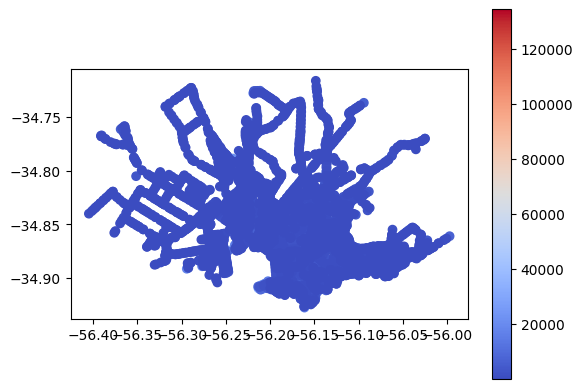

In [ ]:
df_conteo = gdf_merged['geometry'].value_counts().reset_index(name='frecuencia')
gdf_conteo = gpd.GeoDataFrame(df_conteo, geometry='geometry')

plt.figure(figsize=(12, 10))
gdf_conteo.plot(column='frecuencia', cmap='coolwarm', legend=True)

gdf_conteo.info()